In [10]:
from vnstock import *
import pandas as pd
import time
import matplotlib.pyplot as plt
from matplotlib import dates
import math
import squarify
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [2]:
stock = Vnstock().stock(symbol='CMV', source='VCI')
# nvl = stock.quote.history(symbol='NVL', start='2025-04-01', end='2025-06-01', interval='1D')
# dxg = stock.quote.history(symbol='DXG', start='2025-04-01', end='2025-06-01', interval='1D')
vnindex = stock.quote.history(symbol='VNINDEX', start='2025-04-01', end='2025-06-01', interval='1D')

In [3]:
df_total = pd.DataFrame()
for symbol in ['NVL', 'DXG']:
    try:
        df = stock.quote.history(symbol=symbol, start='2025-04-01', end='2025-06-01', interval='1D')
        df['symbol'] = symbol
        df_total = pd.concat([df_total, df], ignore_index=True)
    except ValueError as e:
        print(f"Error for symbol {symbol}: {e}")
    except Exception as e:
        print(f"Unexpected error for symbol {symbol}: {e}")
        
    time.sleep(1)

In [ ]:
def growth_index(df):
    close_last = df.loc[df['time'].idxmax(), 'close']
    close_first = df.loc[df['time'].idxmin(), 'close']
    growth_value = (close_last - close_first) * 100 / close_first
    return growth_value
k
def precompute(stock, sto_ex, name_exchange):
    exchange_index_item = {}
    exchange_index_item['symbol'] = name_exchange
    exchange_index_item['value'] = growth_index(sto_ex)
    
    symbol_stocks = []
    for symbol in stock['symbol'].unique():
        item = {
            'symbol': symbol,
            'value': growth_index(stock[stock['symbol'] == symbol])
        }
        symbol_stocks.append(item)
    
    return exchange_index_item, symbol_stocks

def visualize_overall_growth(dictionary, list_dict, name_exchange):
    index_value = dictionary['value']

    symbols = [symbol_stock['symbol'] for symbol_stock in list_dict]
    values = [symbol_stock['value'] for symbol_stock in list_dict]

    plt.figure(figsize=(12, 6))
    plt.bar(symbols, values, color='skyblue', edgecolor='black')

    plt.axhline(y=index_value, color="red", linestyle="--", linewidth=3, label=f"{name_exchange}: {index_value:.2f}")

    plt.xticks(rotation=90)
    plt.ylabel("Index Value")
    plt.title(f"{name_exchange}")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.show()

In [7]:
def growth_index_per_day(close):
    if close.empty:
        return pd.Series()
    return (close - close.iloc[0]) * 100 / close.iloc[0]

def visualize_all_stock(stock, symbols, sto_ex, name_exchange):
    n = len(symbols)
    cols = 3  # số biểu đồ mỗi hàng
    rows = math.ceil(n / cols)

    fig, axs = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), constrained_layout=True)
    axs = axs.flatten()  # chuyển về 1D array để dễ truy cập

    for i, symbol in enumerate(symbols):
        ax = axs[i]
        time_stock = stock[stock['symbol'] == symbol]['time']
        value_stock = stock[stock['symbol'] == symbol]['close']

        time_exchange = sto_ex['time']
        value_exchange = sto_ex['close']

        ax.plot(time_stock, growth_index_per_day(value_stock), color='blue', label=f"{symbol}")
        ax.plot(time_exchange, growth_index_per_day(value_exchange), color='red', label=name_exchange)

        ax.xaxis.set_major_formatter(dates.DateFormatter('%d-%m-%Y'))
        ax.xaxis.set_major_locator(dates.DayLocator(interval=3)) 
        
        # Xoay nhãn ngày
        for label in ax.get_xticklabels():
            label.set_rotation(45)  
            
        ax.set_title(f"{symbol} vs {name_exchange}", fontsize=10)
        ax.legend(loc='upper left')
        ax.grid(True)
    
    # Xóa subplot trống (nếu có)
    for j in range(i+1, len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.show()
    
def show_one_stock(stock, symbol, sto_ex, name_exchange):
  time_stock = stock[stock['symbol'] == symbol]['time']
  value_stock = stock[stock['symbol'] == symbol]['close']

  time_exchange = sto_ex['time']
  value_exchange = sto_ex['close']
  
  plt.figure(figsize=(10, 6))
  plt.plot(time_stock, growth_index_per_day(value_stock), color='blue', label=f"{symbol}")
  plt.plot(time_exchange, growth_index_per_day(value_exchange), color='red', label=name_exchange)

  plt.gca().xaxis.set_major_formatter(dates.DateFormatter('%d-%m-%Y'))
  plt.gca().xaxis.set_major_locator(dates.DayLocator(interval=1))
  plt.gcf().autofmt_xdate()

  plt.grid(True)
  plt.legend(loc='upper left') 
#   # Cố định scale trục tung
#   plt.ylim(-150, 1500)  # Điều chỉnh tùy theo độ biến động bạn muốn theo dõi

  plt.title(f"{symbol} and {name_exchange}", fontsize=16)

  plt.show() 

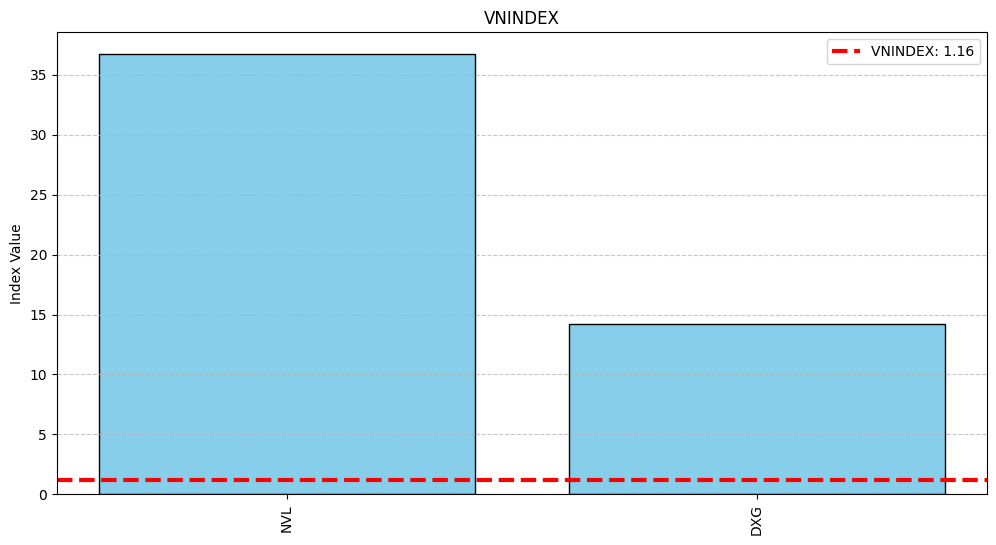

In [8]:
vnindex_dict, hsx_list = precompute(df_total, vnindex, "VNINDEX")
visualize_overall_growth(vnindex_dict, hsx_list, "VNINDEX")

The figure layout has changed to tight


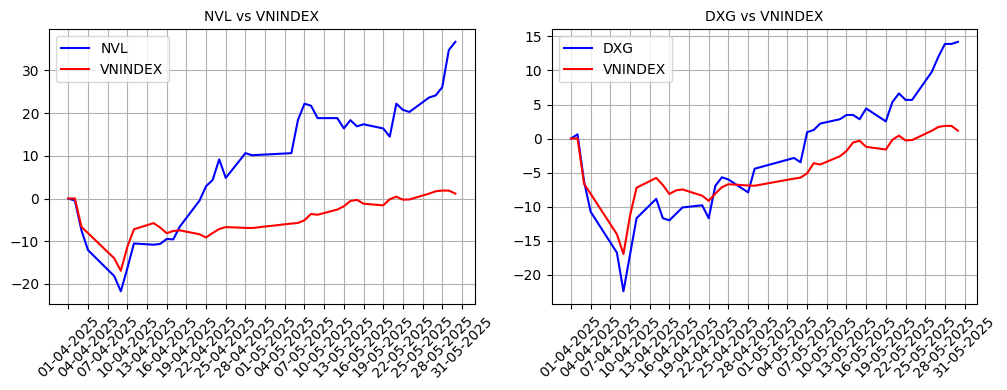

In [9]:
visualize_all_stock(df_total, df_total['symbol'].unique(), vnindex, 'VNINDEX')

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


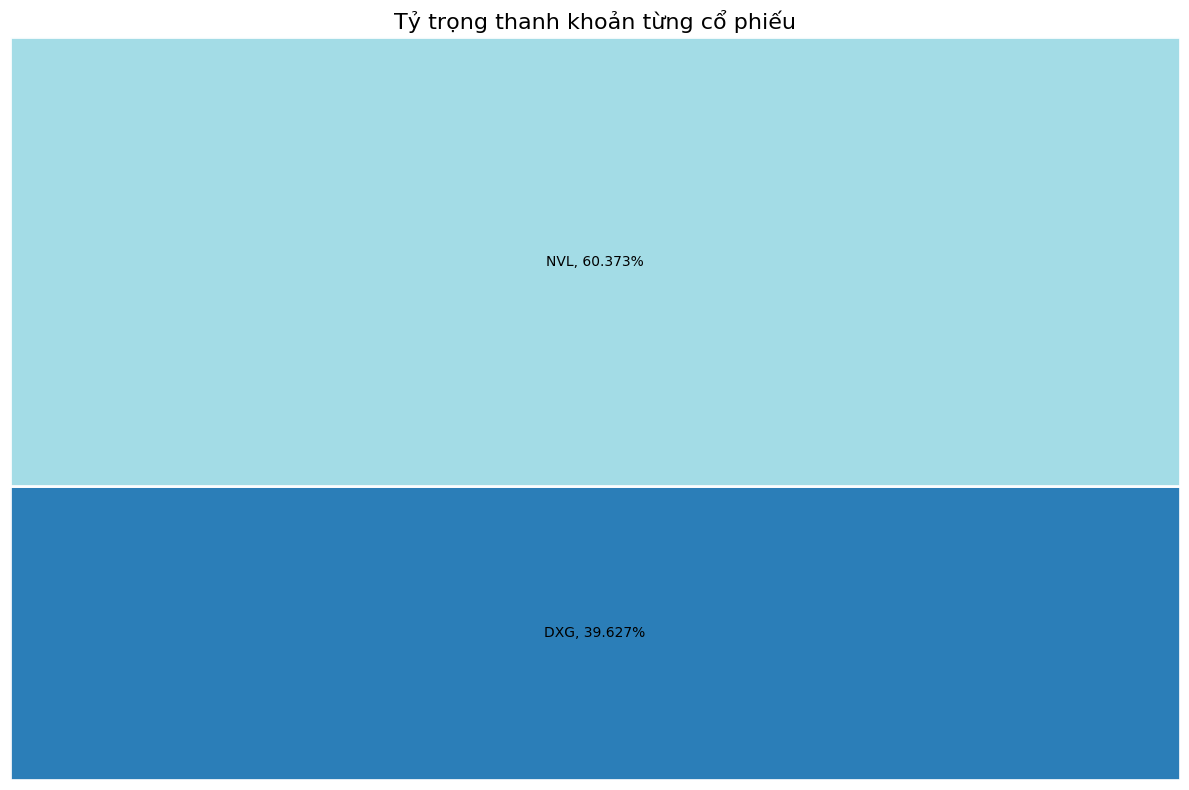

In [11]:
# merge = pd.DataFrame()
# merge_list = [hsx, hnx, upcom]
# for df in merge_list:
#     merge = pd.concat([merge, df], ignore_index=True)
    
# Lấy volume
volume = df_total.groupby('symbol')['volume'].sum()

# Tạo volume dataFrame
df_volume = pd.DataFrame(volume)
df_volume = df_volume.reset_index()

# Tính phần trăm
df_volume['percent'] = df_volume['volume'] / df_volume['volume'].sum() * 100
df_volume['label'] = df_volume['symbol'] + ', ' + df_volume['percent'].round(3).astype(str) + '%'

# Sử dụng colormap để sinh màu tự động (ví dụ: 'tab20' có 20 màu phân biệt)
cmap = cm.get_cmap('tab20', len(df_volume))

# Tạo danh sách màu riêng cho từng cổ phiếu
colors = [mcolors.rgb2hex(cmap(i)) for i in range(len(df_volume))]

# Vẽ treemap
plt.figure(figsize=(12, 8))
squarify.plot(
    sizes=df_volume['volume'],
    label=df_volume['label'],
    color=colors,
    alpha=0.95,
    edgecolor='white',
    linewidth=2
)

plt.title('Tỷ trọng thanh khoản từng cổ phiếu', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

In [12]:
df_volume

,symbol,volume,percent,label
0,DXG,617674900,39.626711,"DXG, 39.627%"
1,NVL,941058800,60.373289,"NVL, 60.373%"


In [15]:
start_date_str = '2024-04-01'
end_date_str = '2024-06-01'

symbols = ['NVL', 'DXG'] # Chỉ lấy cho cổ phiếu, không lấy cho VNINDEX
df_foreign_total = pd.DataFrame()

print("Đang tải dữ liệu giao dịch khối ngoại từ TCBS...")
for symbol in symbols:
    try:
        # Sử dụng Vnstock().stock() để tạo đối tượng cho từng mã nếu cần
        # Hoặc nếu bạn đã có một đối tượng stock_tcbs = Vnstock().stock(source='TCBS') thì dùng stock_tcbs.trading_insights...
        df_foreign_symbol = Vnstock().stock(symbol=symbol, source='MAS').trading_insights.foreign_trade_stats_df(
            symbol=symbol,
            report_type='FR_DAILY_STATS', # Lấy thống kê giao dịch khối ngoại hàng ngày
            # page_num và page_size mặc định thường đủ để lấy lịch sử dài
        )
        
        if df_foreign_symbol is not None and not df_foreign_symbol.empty:
            # Đổi tên cột ngày và chuyển sang kiểu datetime
            df_foreign_symbol.rename(columns={'tradingDate': 'time'}, inplace=True) # TCBS dùng tradingDate
            df_foreign_symbol['time'] = pd.to_datetime(df_foreign_symbol['time'])
            
            # Lọc theo ngày
            df_foreign_symbol_filtered = df_foreign_symbol[
                (df_foreign_symbol['time'] >= start_date_str) &
                (df_foreign_symbol['time'] <= end_date_str)
            ].copy() # Thêm .copy() để tránh SettingWithCopyWarning

            if not df_foreign_symbol_filtered.empty:
                # Tính tổng khối lượng giao dịch của khối ngoại (mua + bán)
                # Hoặc bạn có thể chỉ quan tâm đến KL mua (foreignBuyQuantity) hoặc KL bán (foreignSellQuantity)
                # hoặc KL mua ròng (foreignNetBuySellQuantity)
                # Ở đây ta tính tổng KL tham gia của khối ngoại
                df_foreign_symbol_filtered['foreign_total_volume'] = df_foreign_symbol_filtered['foreignBuyQuantity'] + df_foreign_symbol_filtered['foreignSellQuantity']
                df_foreign_symbol_filtered['symbol'] = symbol
                df_foreign_total = pd.concat([df_foreign_total, df_foreign_symbol_filtered[['time', 'symbol', 'foreign_total_volume', 'foreignBuyQuantity', 'foreignSellQuantity', 'foreignNetBuySellQuantity']]], ignore_index=True)
            else:
                print(f"Không có dữ liệu khối ngoại cho {symbol} trong khoảng thời gian đã chọn.")
        else:
            print(f"Không lấy được dữ liệu khối ngoại cho {symbol} từ TCBS.")
            
    except Exception as e:
        print(f"Lỗi khi lấy dữ liệu khối ngoại cho {symbol}: {e}")

if not df_foreign_total.empty:
    # Lấy tổng volume giao dịch của khối ngoại cho mỗi cổ phiếu
    # Đổi tên cột 'foreign_total_volume' thành 'volume' để phù hợp với code vẽ biểu đồ hiện tại
    volume_foreign = df_foreign_total.groupby('symbol')['foreign_total_volume'].sum()

    # Tạo volume dataFrame
    df_volume_foreign = pd.DataFrame(volume_foreign)
    df_volume_foreign.rename(columns={'foreign_total_volume': 'volume'}, inplace=True)
    df_volume_foreign = df_volume_foreign.reset_index()

    if not df_volume_foreign.empty and df_volume_foreign['volume'].sum() > 0:
        # Tính phần trăm
        df_volume_foreign['percent'] = df_volume_foreign['volume'] / df_volume_foreign['volume'].sum() * 100
        df_volume_foreign['label'] = df_volume_foreign['symbol'] + ', ' + df_volume_foreign['percent'].round(3).astype(str) + '%'

        # Sử dụng colormap để sinh màu tự động
        cmap = cm.get_cmap('tab20', len(df_volume_foreign))
        colors = [mcolors.rgb2hex(cmap(i)) for i in range(len(df_volume_foreign))]

        # Vẽ treemap
        plt.figure(figsize=(12, 8))
        squarify.plot(
            sizes=df_volume_foreign['volume'],
            label=df_volume_foreign['label'],
            color=colors,
            alpha=0.95,
            edgecolor='white',
            linewidth=2
        )
        plt.title(f'Tỷ trọng thanh khoản KHỐI NGOẠI từng cổ phiếu ({start_date_str} đến {end_date_str})', fontsize=16)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    else:
        print("Không có dữ liệu khối lượng giao dịch khối ngoại để vẽ biểu đồ.")
else:
    print("Không lấy được bất kỳ dữ liệu giao dịch khối ngoại nào.")

Đang tải dữ liệu giao dịch khối ngoại từ TCBS...
Lỗi khi lấy dữ liệu khối ngoại cho NVL: Chỉ có nguồn dữ liệu từ VCI, TCBS, MSN được hỗ trợ.
Lỗi khi lấy dữ liệu khối ngoại cho DXG: Chỉ có nguồn dữ liệu từ VCI, TCBS, MSN được hỗ trợ.
Không lấy được bất kỳ dữ liệu giao dịch khối ngoại nào.
